Loading CSV data... Total records: 257

 Patient-level summary successfully saved to:
   C:\Users\ishin\OneDrive\Desktop\Ishini\images\patient_level_summary.csv

PATIENT-LEVEL SUMMARY REPORT
Patient_ID  Total_Images  Mean_Thickness_nm  Median_Thickness_nm  Std_Dev_nm Final_Category
     01-24            15          38.845593            22.577754   38.050391           Thin
     02-24            29          35.862471            20.673895   33.467284           Thin
     03-24            15          66.511339            26.045465   76.396752         Normal
     04-23            31          35.193763            21.782200   31.616265           Thin
     05-24            15          44.953154            24.171421   44.349999           Thin
     06-24            16          33.250712            19.502708   29.451889           Thin
     07-25            16          30.109912            19.802000   25.436201           Thin
     08-25            15          40.953056            26.933632   34.329

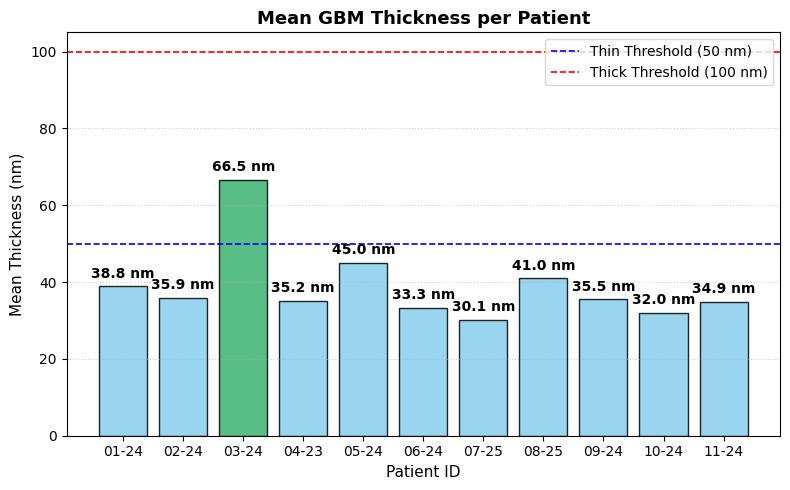


 Comparison Plot saved to:
   C:\Users\ishin\OneDrive\Desktop\Ishini\images\patient_thickness_comparison.png


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
IMAGE_FOLDER = r"C:\Users\ishin\OneDrive\Desktop\Ishini\images"
INPUT_CSV = os.path.join(IMAGE_FOLDER, "gbm_thickness_results.csv")
OUTPUT_PATIENT_CSV = os.path.join(IMAGE_FOLDER, "patient_level_summary.csv")
OUTPUT_BAR_PLOT = os.path.join(IMAGE_FOLDER, "patient_thickness_comparison.png")

# Patient Classification Thresholds (in nm)
# Thin: < 50 nm | Normal: 50 - 100 nm | Thick: > 100 nm
def classify_patient(mean_nm):
    if mean_nm < 50.0:
        return "Thin"
    elif 50.0 <= mean_nm <= 100.0:
        return "Normal"
    else:
        return "Thick"

# ==========================================
# 2. MAIN AGGREGATION LOGIC
# ==========================================
def summarize_patient_data():
    if not os.path.exists(INPUT_CSV):
        print(f" Error: `{INPUT_CSV}` Cannot be found. Please run the first script.")
        return

    # Load results CSV
    df = pd.read_csv(INPUT_CSV)
    
    print(f"Loading CSV data... Total records: {len(df)}")

    # Group by Patient_ID
    patient_summary = df.groupby("Patient_ID").agg(
        Total_Images=("Filename", "count"),
        Mean_Thickness_nm=("Mean_Thickness_nm", "mean"),
        Median_Thickness_nm=("Median_Thickness_nm", "median"),
        Std_Dev_nm=("Std_Dev_nm", "mean")
    ).reset_index()

    # Assign Final Diagnosis/Category per Patient
    patient_summary["Final_Category"] = patient_summary["Mean_Thickness_nm"].apply(classify_patient)

    # Save to CSV
    patient_summary.to_csv(OUTPUT_PATIENT_CSV, index=False)
    print(f"\n Patient-level summary successfully saved to:\n   {OUTPUT_PATIENT_CSV}\n")
    
    # Print Summary Table in Console
    print("==========================================================")
    print("PATIENT-LEVEL SUMMARY REPORT")
    print("==========================================================")
    print(patient_summary.to_string(index=False))
    print("==========================================================")

    # ==========================================
    # 3. VISUALIZATION (PATIENT COMPARISON BAR CHART)
    # ==========================================
    plt.figure(figsize=(8, 5))
    bars = plt.bar(patient_summary["Patient_ID"], patient_summary["Mean_Thickness_nm"], 
                   color=['mediumseagreen' if cat == 'Normal' else 'salmon' if cat == 'Thick' else 'skyblue' 
                          for cat in patient_summary["Final_Category"]],
                   edgecolor='black', alpha=0.85)

    # Threshold lines
    plt.axhline(y=50, color='blue', linestyle='--', linewidth=1.2, label='Thin Threshold (50 nm)')
    plt.axhline(y=100, color='red', linestyle='--', linewidth=1.2, label='Thick Threshold (100 nm)')

    # Add Value Labels on Top of Bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                 f'{height:.1f} nm', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title("Mean GBM Thickness per Patient", fontsize=13, fontweight='bold')
    plt.xlabel("Patient ID", fontsize=11)
    plt.ylabel("Mean Thickness (nm)", fontsize=11)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()

    plt.savefig(OUTPUT_BAR_PLOT, dpi=300)
    plt.show()
    print(f"\n Comparison Plot saved to:\n   {OUTPUT_BAR_PLOT}")

if __name__ == "__main__":
    summarize_patient_data()